In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm

# Lê o dataset de Pokémon
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Card 13/pratica/Pokemon.csv")

# Escolhe apenas as colunas que vamos usar
features = ['Attack', 'Speed']

# Remove linhas com valores vazios nessas colunas
df = df[features + ['Type 1']].dropna()

# Dados de entrada (Attack e Speed)
X = df[features].values

# Classe (tipo do Pokémon convertido em números)
y = df['Type 1'].astype('category').cat.codes.values

# Guarda os nomes reais dos tipos (para depois converter de volta)
labels = df['Type 1'].astype('category').cat.categories

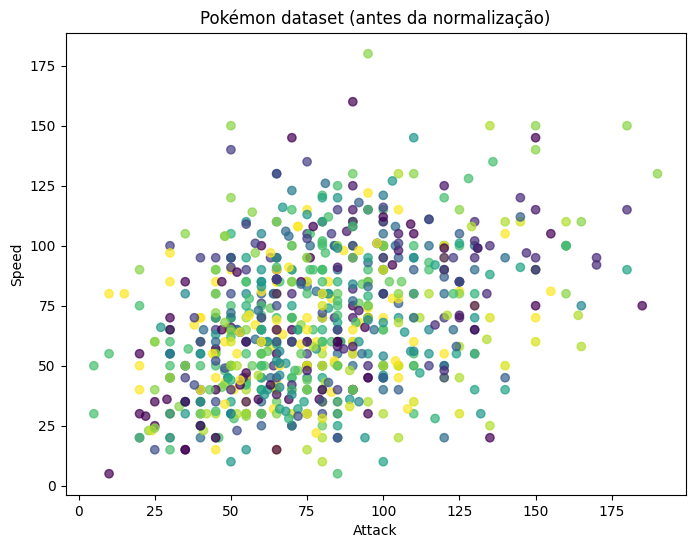

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],  # Attack
    X[:,1],  # Speed
    c=y,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Attack")
plt.ylabel("Speed")
plt.title("Pokémon dataset (antes da normalização)")
plt.show()

In [21]:
# Coloca os valores na mesma escala (-1 a 1)
scaler = MinMaxScaler(feature_range=(-1, 1)).fit(X)

# Aplica a transformação
X_scaled = scaler.transform(X)

In [22]:
# Cria e treina o modelo SVM com kernel linear
svc = svm.SVC(kernel='linear', C=1.0).fit(X_scaled, y)

In [27]:
def predictPokemon(clf, X_data, y_data):

    # Cria uma grade de pontos para o gráfico
    xx, yy = np.meshgrid(
        np.arange(-1.1, 1.1, 0.02),
        np.arange(-1.1, 1.1, 0.02)
    )

    # Faz previsão para cada ponto da grade
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Remodela para formato da grade
    Z = Z.reshape(xx.shape)

    # Cria figura
    plt.figure(figsize=(10,8))

    # Desenha regiões de decisão
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

    # Desenha os pontos reais
    plt.scatter(
        X_data[:,0],
        X_data[:,1],
        c=y_data,
        edgecolors='k',
        cmap=plt.cm.Paired
    )

    plt.xlabel("Attack (normalizado)")
    plt.ylabel("Speed (normalizado)")
    plt.title("Regiões de decisão do SVM")
    plt.show()

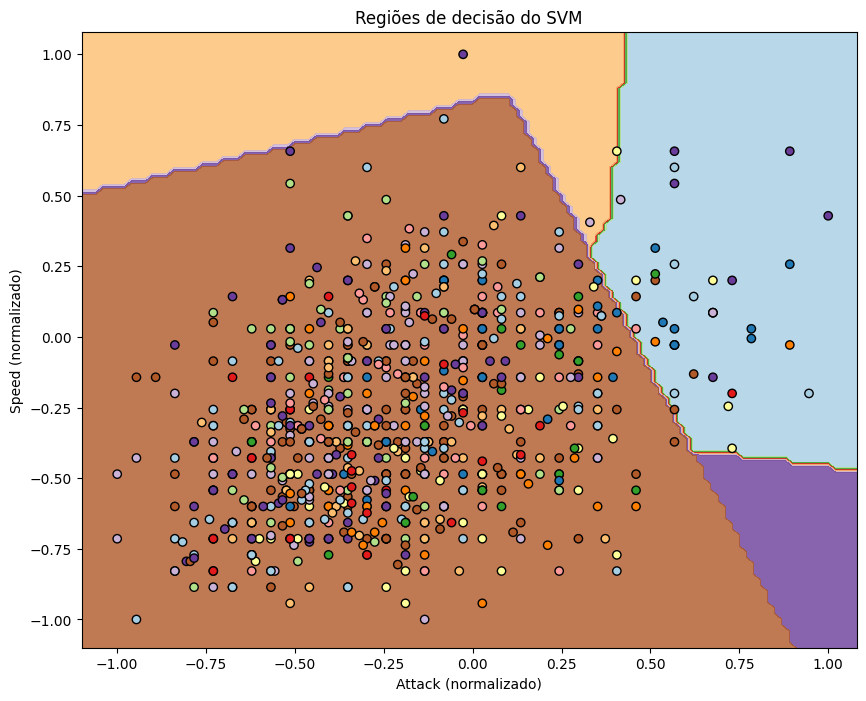

In [28]:
predictPokemon(svc, X_scaled, y)

In [29]:
# Pokémon fictício (Attack, Speed)
teste = [[110, 95]]

# Normaliza antes de prever
predicao = svc.predict(scaler.transform(teste))

# Mostra o tipo previsto
print(labels[predicao[0]])

Water
